# Hosted teleop TwistStamped latency

End-to-end latency for the keyboard → Cloudflare WebRTC → robot path.

- **Source stamp** (`o.data.ts`): set in the browser when the key/state was sampled, encoded into the `TwistStamped.header.stamp`.
- **Recorder stamp** (`o.ts`): time the recorder ingested the published message on the robot.

`latency = o.ts - o.data.ts` covers send → WebRTC SFU → decode → republish → record. Assumes browser and robot clocks are roughly NTP-synced; if they aren't, the histogram shape is still meaningful (jitter), only the absolute offset is off.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from dimos.memory2.store.sqlite import SqliteStore

RECORDING_PATH = Path("../../../recording_hosted_3.db")

store = SqliteStore(path=str(RECORDING_PATH))
obs = {name: stream.to_list() for name, stream in store.streams.items()}

print(f"recording: {RECORDING_PATH.name}")
for name in obs:
    print(f"  {store.streams[name].summary()}")

recording: recording_hosted_3.db
  Stream("buttons"): 7164 items, 2026-05-10 00:39:11 — 2026-05-10 00:42:07 (176.5s)
  Stream("cmd_vel_stamped"): 10613 items, 2026-05-10 00:39:24 — 2026-05-10 00:42:07 (163.0s)
  Stream("left_controller_output"): empty
  Stream("right_controller_output"): empty


## Latency: source → recorder

Histogram (log y) with p50/p95/p99 markers. Negative values = browser clock ahead of robot clock; large positive tail = network/process stalls.

dropped 480/10613 outliers outside [-8.5, 158.6] ms
n=10133  min=49.3  p50=66.3  p95=130.1  p99=149.2  max=158.6  mean=75.9 ms


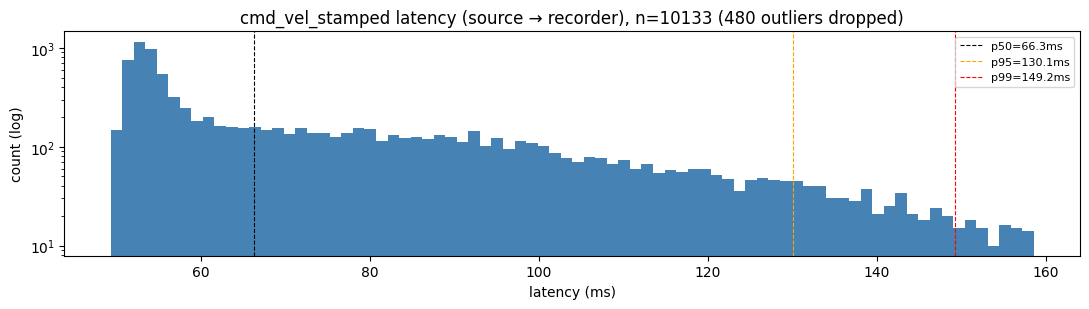

In [2]:
# Tukey IQR fence — drop samples outside [Q1 - K*IQR, Q3 + K*IQR].
OUTLIER_K = 1.5

twist = obs.get("cmd_vel_stamped", [])
if not twist:
    print("no cmd_vel_stamped stream")
else:
    src = np.array([o.data.ts for o in twist])
    rec = np.array([o.ts for o in twist])
    lat_ms_all = (rec - src) * 1000.0

    q1, q3 = np.percentile(lat_ms_all, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - OUTLIER_K * iqr, q3 + OUTLIER_K * iqr
    mask = (lat_ms_all >= lo) & (lat_ms_all <= hi)
    lat_ms = lat_ms_all[mask]
    rec_inlier = rec[mask]
    dropped = len(lat_ms_all) - len(lat_ms)
    print(f"dropped {dropped}/{len(lat_ms_all)} outliers outside [{lo:.1f}, {hi:.1f}] ms")

    p50, p95, p99 = np.percentile(lat_ms, [50, 95, 99])
    print(
        f"n={len(lat_ms)}  min={lat_ms.min():.1f}  p50={p50:.1f}  p95={p95:.1f}  "
        f"p99={p99:.1f}  max={lat_ms.max():.1f}  mean={lat_ms.mean():.1f} ms"
    )

    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.hist(lat_ms, bins=80, log=True, color="steelblue", edgecolor="none")
    for p, c, lbl in [(p50, "black", "p50"), (p95, "orange", "p95"), (p99, "red", "p99")]:
        ax.axvline(p, color=c, linestyle="--", lw=0.8, label=f"{lbl}={p:.1f}ms")
    ax.set_title(
        f"cmd_vel_stamped latency (source → recorder), n={len(lat_ms)} ({dropped} outliers dropped)"
    )
    ax.set_xlabel("latency (ms)")
    ax.set_ylabel("count (log)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Latency over time

Drift or burst stalls show up here. Steady horizontal band = stable transport; ramps = clock drift; spikes = network jitter / SFU / GC.

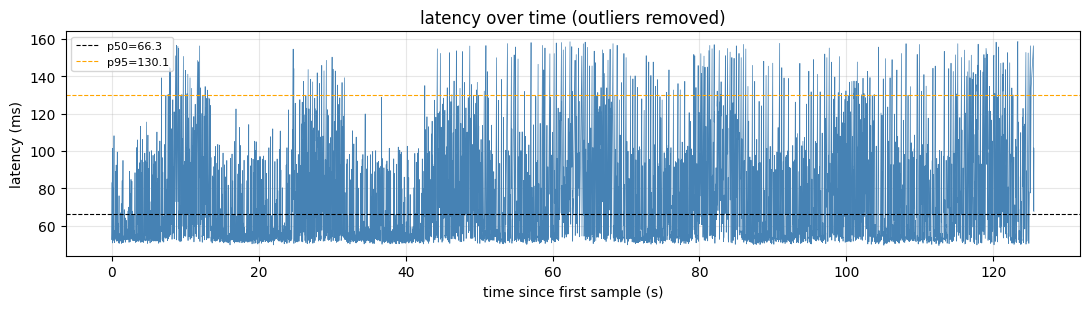

In [3]:
if twist:
    rel = rec_inlier - rec_inlier[0]
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(rel, lat_ms, lw=0.5, color="steelblue")
    ax.axhline(p50, color="black", ls="--", lw=0.8, label=f"p50={p50:.1f}")
    ax.axhline(p95, color="orange", ls="--", lw=0.8, label=f"p95={p95:.1f}")
    ax.set_xlabel("time since first sample (s)")
    ax.set_ylabel("latency (ms)")
    ax.set_title("latency over time (outliers removed)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Inter-arrival jitter

Source-side cadence (browser sendInterval) vs recorder-side cadence. If recorder intervals are much wider than source intervals, the transport is bunching/dropping.

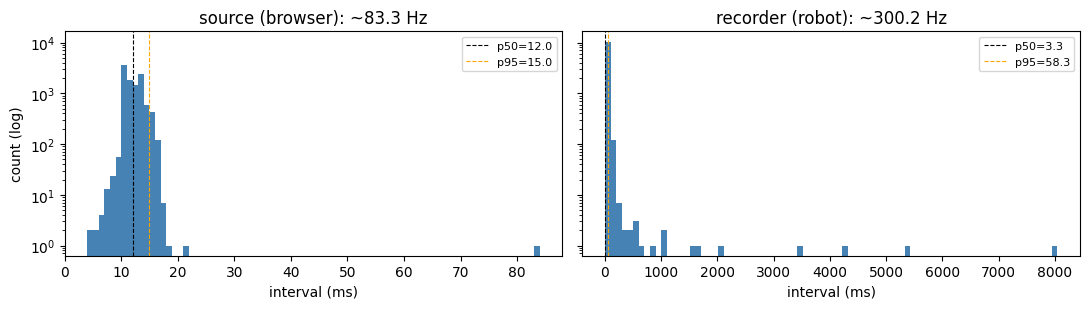

In [4]:
if twist:
    src_iv = np.diff(np.sort(src)) * 1000.0
    rec_iv = np.diff(np.sort(rec)) * 1000.0
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
    for ax, iv, lbl in [(axes[0], src_iv, "source (browser)"), (axes[1], rec_iv, "recorder (robot)")]:
        rate = 1000.0 / np.median(iv)
        p50, p95 = np.percentile(iv, [50, 95])
        ax.hist(iv, bins=80, log=True, color="steelblue", edgecolor="none")
        ax.axvline(p50, color="black", ls="--", lw=0.8, label=f"p50={p50:.1f}")
        ax.axvline(p95, color="orange", ls="--", lw=0.8, label=f"p95={p95:.1f}")
        ax.set_title(f"{lbl}: ~{rate:.1f} Hz")
        ax.set_xlabel("interval (ms)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("count (log)")
    plt.tight_layout()
    plt.show()